# WEASEL v2 — n_jobs scaling: aeon threads vs process pool

Full `fit_transform` on the TwoPatterns training set (1000 series × 128) with aeon's
`WEASELTransformerV2` at its default parameters except **`feature_selection="none"`** (as the
project uses it; 150 configurations × 2 = 300 SFA members), for n_jobs ∈ {1, 2, 4, 8, 16}:

* **aeon (original)** — `aeon.classification.dictionary_based._weasel_v2.WEASELTransformerV2`,
  which runs its configurations with joblib **threads**.
* **process pool** — the same aeon function (`_parallel_fit`) for each configuration, with the same
  arguments, in a joblib `loky` **process** pool. Nothing else changes, and the output is checked
  cell-for-cell against aeon.

Why they differ: aeon's per-member numba code holds the GIL (`_mft` is `@njit` without `nogil`, and
the breakpoint fit re-enters Python once per series for a scipy FFT), so threads take turns, while
each process has its own interpreter. The price is memory — every process allocates its own
temporaries — so the RAM used by the kernel and its worker processes is recorded as well.

In [1]:
import io
import sys
import threading
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from aeon.classification.dictionary_based import _weasel_v2 as W
from aeon.classification.dictionary_based._weasel_v2 import WEASELTransformerV2
from joblib import Parallel, delayed

from tscglue.utils import load_dataset

DATASET = "FordB"
SEED = 153153030
GRID = [1, 2, 4, 8, 16]

X_train, y_train, X_test, y_test = load_dataset(DATASET)
print(X_train.shape, "| cpus:", psutil.cpu_count(), "| free RAM:",
      f"{psutil.virtual_memory().available / 1e9:.0f} GB")

/export/home/gpetelin/TSCGlue/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(3636, 1, 500) | cpus: 32 | free RAM: 115 GB


In [2]:
def _ignore_bytesio_buffer_error(unraisable):
    """Drop loky's harmless "Exception ignored in: <_io.BytesIO ...> BufferError" cleanup messages."""
    if isinstance(unraisable.exc_value, BufferError) and isinstance(unraisable.object, io.BytesIO):
        return
    sys.__unraisablehook__(unraisable)


def _parallel_fit_quiet(*args):
    # Runs in the worker process; the hook stays installed for the worker's lifetime.
    sys.unraisablehook = _ignore_bytesio_buffer_error
    return W._parallel_fit(*args)


class WEASELv2Processes:
    """aeon's WEASELTransformerV2.fit_transform with the ensemble loop in a process pool.

    A copy of aeon 1.5's ``fit_transform`` with aeon's defaults except ``feature_selection``: the same ensemble-size / window
    rules and the same ``_parallel_fit`` call per configuration; only
    ``Parallel(prefer="threads")`` becomes ``Parallel(backend="loky")`` (with a worker-side hook
    that silences loky's harmless BytesIO cleanup messages).
    """

    def __init__(self, min_window=4, norm_options=(False,), word_lengths=(7, 8),
                 use_first_differences=(True, False), feature_selection="none",
                 max_feature_count=30_000, random_state=None, n_jobs=1):
        self.min_window = min_window
        self.norm_options = norm_options
        self.word_lengths = word_lengths
        self.use_first_differences = use_first_differences
        self.feature_selection = feature_selection
        self.max_feature_count = max_feature_count
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit_transform(self, X, y=None):
        XX = X.squeeze(1)
        n_cases, n_timepoints = XX.shape
        if n_cases < W.SWITCH_SMALL_INSTANCES:
            max_window, ensemble_size = W.MAX_WINDOW_SMALL, W.ENSEMBLE_SIZE_SMALL
        elif n_timepoints < W.SWITCH_MEDIUM_LENGTH:
            max_window, ensemble_size = W.MAX_WINDOW_MEDIUM, W.ENSEMBLE_SIZE_MEDIUM
        else:
            max_window, ensemble_size = W.MAX_WINDOW_LARGE, W.ENSEMBLE_SIZE_LARGE
        window_sizes = np.arange(self.min_window, int(min(n_timepoints, max_window)) + 1)

        res = Parallel(n_jobs=self.n_jobs, backend="loky")(
            delayed(_parallel_fit_quiet)(
                i, XX, y.copy(), window_sizes, [2], self.word_lengths, n_timepoints,
                self.norm_options, self.use_first_differences, ["equi-depth", "equi-width"],
                True, False, False, True, self.n_jobs, self.max_feature_count, ensemble_size,
                self.feature_selection, False, self.random_state,
            )
            for i in range(ensemble_size)
        )
        self.SFA_transformers = [t for _, ts in res for t in ts]
        return np.concatenate([w for ws, _ in res for w in ws], axis=1)


class PeakRSS:
    """Peak resident memory of this kernel plus all its child processes while the block runs.

    Approximate: pages shared between processes (numpy, numba, ...) are counted once per process.
    """

    def __init__(self, interval=0.5):
        self.interval = interval

    def _total(self):
        proc = psutil.Process()
        total = proc.memory_info().rss
        for child in proc.children(recursive=True):
            try:
                total += child.memory_info().rss
            except psutil.Error:
                pass
        return total

    def _watch(self):
        while not self._stop.wait(self.interval):
            self.peak = max(self.peak, self._total())

    def __enter__(self):
        self.start = self.peak = self._total()
        self._stop = threading.Event()
        self._thread = threading.Thread(target=self._watch, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, *exc):
        self._stop.set()
        self._thread.join()
        self.peak = max(self.peak, self._total())

## Run

Each timed run is preceded by a small warm-up (numba cache loading, and for the process pool the
start-up of `n_jobs` workers), so the timings are the steady state a pipeline would see.

In [3]:
IMPLS = ["aeon threads (original)", "process pool"]


def make(impl, n_jobs):
    if impl == IMPLS[0]:
        return WEASELTransformerV2(random_state=SEED, n_jobs=n_jobs, feature_selection="none")
    return WEASELv2Processes(random_state=SEED, n_jobs=n_jobs)


rows, reference = [], None
for impl in IMPLS:
    for n_jobs in GRID:
        make(impl, n_jobs).fit_transform(X_train[:60], y_train[:60])  # warm-up
        with PeakRSS() as mem:
            t0 = time.perf_counter()
            Xt = make(impl, n_jobs).fit_transform(X_train, y_train)
            seconds = time.perf_counter() - t0
        if reference is None:
            reference = Xt
        rows.append({
            "implementation": impl,
            "n_jobs": n_jobs,
            "seconds": seconds,
            "extra RAM, GB": (mem.peak - mem.start) / 1e9,
            "peak RAM, GB": mem.peak / 1e9,
            "identical to aeon n_jobs=1": np.array_equal(Xt, reference),
        })
        print(f"{impl:<24} n_jobs={n_jobs:<3} {seconds:7.1f}s  shape={Xt.shape}  "
              f"extra RAM {rows[-1]['extra RAM, GB']:.1f} GB  identical={rows[-1]['identical to aeon n_jobs=1']}",
              flush=True)

results = pd.DataFrame(rows)
base = results.loc[(results["implementation"] == IMPLS[0]) & (results["n_jobs"] == 1), "seconds"].item()
results["speed-up vs aeon n_jobs=1"] = base / results["seconds"]
results.round(2)

aeon threads (original)  n_jobs=1     182.8s  shape=(3636, 73800)  extra RAM 1.4 GB  identical=True
aeon threads (original)  n_jobs=2     176.6s  shape=(3636, 73800)  extra RAM 2.2 GB  identical=True
aeon threads (original)  n_jobs=4     184.1s  shape=(3636, 73800)  extra RAM 1.9 GB  identical=True
aeon threads (original)  n_jobs=8     195.5s  shape=(3636, 73800)  extra RAM 2.3 GB  identical=True
aeon threads (original)  n_jobs=16    202.7s  shape=(3636, 73800)  extra RAM 2.0 GB  identical=True
process pool             n_jobs=1     180.2s  shape=(3636, 73800)  extra RAM 1.0 GB  identical=True
process pool             n_jobs=2      90.8s  shape=(3636, 73800)  extra RAM 1.6 GB  identical=True
process pool             n_jobs=4      46.4s  shape=(3636, 73800)  extra RAM 1.8 GB  identical=True
process pool             n_jobs=8      30.1s  shape=(3636, 73800)  extra RAM 3.3 GB  identical=True
process pool             n_jobs=16     25.1s  shape=(3636, 73800)  extra RAM 4.8 GB  identical=True


,implementation,n_jobs,seconds,"extra RAM, GB","peak RAM, GB",identical to aeon n_jobs=1,speed-up vs aeon n_jobs=1
0,aeon threads (original),1,182.81,1.36,1.75,True,1.00
1,aeon threads (original),2,176.57,2.20,3.98,True,1.04
2,aeon threads (original),4,184.09,1.91,5.10,True,0.99
3,aeon threads (original),8,195.47,2.27,5.82,True,0.94
4,aeon threads (original),16,202.74,2.00,6.38,True,0.90
5,process pool,1,180.17,1.02,6.29,True,1.01
6,process pool,2,90.77,1.61,7.40,True,2.01
7,process pool,4,46.35,1.83,8.28,True,3.94
8,process pool,8,30.05,3.27,11.00,True,6.08
9,process pool,16,25.05,4.81,15.35,True,7.30


## Graph

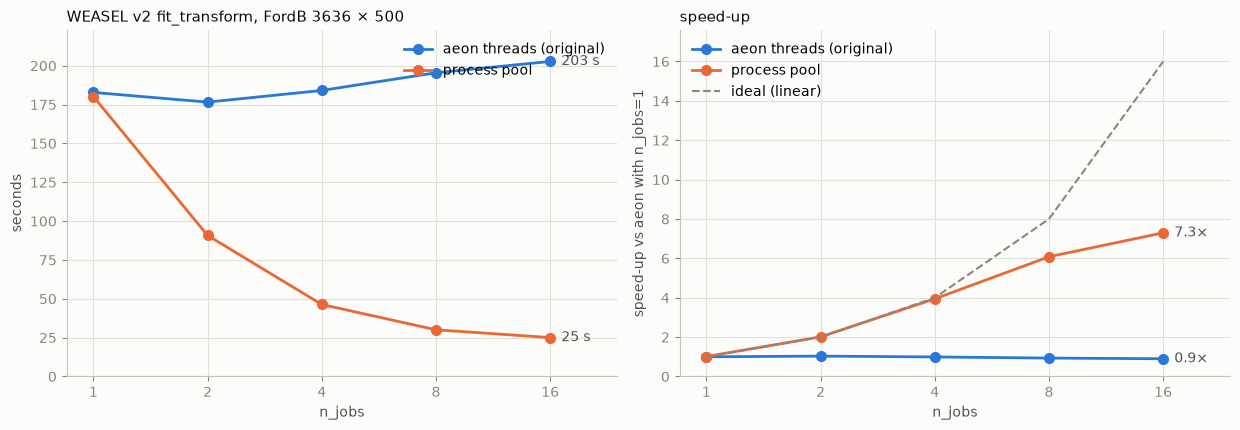

In [4]:
INK2, MUTED = "#52514e", "#898781"
GRIDLINE, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
COLOR = {IMPLS[0]: "#2a78d6", IMPLS[1]: "#eb6834"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "axes.titlecolor": "#0b0b0b", "axes.titlesize": 11,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8, "font.size": 10,
})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

for impl in IMPLS:
    d = results[results["implementation"] == impl]
    ax1.plot(d["n_jobs"], d["seconds"], marker="o", ms=7, lw=2, color=COLOR[impl], label=impl)
    ax2.plot(d["n_jobs"], d["speed-up vs aeon n_jobs=1"], marker="o", ms=7, lw=2, color=COLOR[impl],
             label=impl)
    for ax, col, fmt in [(ax1, "seconds", "{:.0f} s"), (ax2, "speed-up vs aeon n_jobs=1", "{:.1f}×")]:
        ax.annotate(fmt.format(d[col].iloc[-1]), (d["n_jobs"].iloc[-1], d[col].iloc[-1]),
                    xytext=(8, 0), textcoords="offset points", va="center", color=INK2)
ax2.plot(GRID, GRID, ls="--", lw=1.5, color=MUTED, label="ideal (linear)")

for ax in (ax1, ax2):
    ax.set_xscale("log", base=2)
    ax.set_xticks(GRID, [str(g) for g in GRID])
    ax.set_xlim(0.85, GRID[-1] * 1.5)
    ax.set_xlabel("n_jobs")
ax1.set_ylim(0, results["seconds"].max() * 1.1)
ax1.set_ylabel("seconds")
ax1.set_title(f"WEASEL v2 fit_transform, {DATASET} {X_train.shape[0]} × {X_train.shape[-1]}",
              loc="left")
ax1.legend(frameon=False, loc="upper right")
ax2.set_ylim(0, GRID[-1] * 1.1)
ax2.set_ylabel("speed-up vs aeon with n_jobs=1")
ax2.set_title("speed-up", loc="left")
ax2.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

In [5]:
results.pivot(index="n_jobs", columns="implementation",
              values=["seconds", "speed-up vs aeon n_jobs=1", "extra RAM, GB"]).round(2)

seconds              speed-up vs aeon n_jobs=1  \
implementation aeon threads (original) process pool   aeon threads (original)   
n_jobs                                                                          
1                               182.81       180.17                      1.00   
2                               176.57        90.77                      1.04   
4                               184.09        46.35                      0.99   
8                               195.47        30.05                      0.94   
16                              202.74        25.05                      0.90   

                                      extra RAM, GB               
implementation process pool aeon threads (original) process pool  
n_jobs                                                            
1                      1.01                    1.36         1.02  
2                      2.01                    2.20         1.61  
4                      3.94                    1.91         1.83  
8                      6.08                    2.27         3.27  
16                     7.30                    2.00         4.81